# Retrieval-Augmented Generation (RAG): Embeddings and Similarity Search

## Introduction

**Retrieval-Augmented Generation (RAG)** is an architecture that enhances Large Language Model (LLM) responses by first retrieving relevant documents from a knowledge base, then using those documents as context for generation:

```
User query
    ↓
[1] Embed query → dense vector
    ↓
[2] Nearest-neighbour search over document vectors
    ↓
[3] Top-k retrieved documents + query → LLM → answer
```

This notebook focuses on **steps 1 and 2**: building a searchable document corpus using embeddings and cosine similarity.

> **Note:** For teaching purposes we use TF-IDF + SVD as the embedding space. In production RAG you would use a semantic embedding model (e.g., `sentence-transformers`, OpenAI embeddings).

## What Are Embeddings?

An **embedding** maps a piece of text to a dense vector $\mathbf{e} \in \mathbb{R}^d$:

$$\text{embed}: \text{text} \longrightarrow \mathbb{R}^d$$

The fundamental property: **semantically similar texts should have nearby vectors**.

| Approach | Vector type | Semantic understanding |
|----------|------------|----------------------|
| One-hot encoding | sparse, $\mathbb{R}^{\|V\|}$ | None |
| TF-IDF | sparse, $\mathbb{R}^{\|V\|}$ | Lexical only |
| Word2Vec / GloVe | dense, $\mathbb{R}^d$ | Word-level |
| BERT / SentenceTransformers | dense, $\mathbb{R}^d$ | Full sentence semantics |

## TF-IDF: Term Frequency–Inverse Document Frequency

TF-IDF represents a document as a weighted bag-of-words vector. Each dimension corresponds to a term in the vocabulary.

**Term Frequency (TF):** how often term $t$ appears in document $d$:
$$\text{tf}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total terms in } d}$$

**Inverse Document Frequency (IDF):** how rare the term is across all $N$ documents:
$$\text{idf}(t) = \log \frac{N}{|\{d : t \in d\}|}$$

**TF-IDF score:**
$$\text{tfidf}(t, d) = \text{tf}(t, d) \cdot \text{idf}(t)$$

Common words ("the", "is") get low IDF; rare but informative words ("espresso", "gofre") get high IDF.

**Limitation:** TF-IDF has no semantic understanding. "café" and "coffee" have zero similarity in TF-IDF space despite being synonyms.

## Dimensionality Reduction: Truncated SVD (LSA)

A TF-IDF matrix $X \in \mathbb{R}^{N \times |V|}$ is high-dimensional and sparse. **Latent Semantic Analysis (LSA)** applies truncated SVD to find a lower-dimensional dense representation:

$$X \approx U_k \Sigma_k V_k^\top$$

The rows of $U_k \Sigma_k \in \mathbb{R}^{N \times k}$ are the document embeddings. Dimensionality reduction:
- Removes noise
- Groups synonymous terms (they share latent dimensions)
- Enables efficient nearest-neighbour search

## Cosine Similarity

For text embeddings, **cosine similarity** is preferred over Euclidean distance because it is **magnitude-invariant** — only the direction of the vector matters, not its length:

$$\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|\,\|\mathbf{b}\|}$$

**Cosine distance:** $d(\mathbf{a}, \mathbf{b}) = 1 - \cos(\theta) \in [0, 2]$

- $d = 0$: identical direction (maximally similar)
- $d = 1$: orthogonal (unrelated)
- $d = 2$: opposite directions

## Roadmap

1. Build a TF-IDF vectorizer on a small coffee-shop corpus
2. Reduce dimensions with SVD (LSA) and PCA for 2D visualisation
3. Embed a query and find its nearest neighbours
4. Visualise the corpus and query in 2D

## Build the TF-IDF Corpus

We work with 13 Spanish coffee-shop descriptions. The TF-IDF vectorizer converts each document into a sparse feature vector weighted by term importance.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA

# --- Corpus: 13 coffee-shop descriptions (in Spanish) ---
docs = [
    "Cafetería de especialidad con espresso de origen único y baristas expertos en latte art.",
    "Gofrería moderna que sirve gofres belgas con toppings de frutas frescas y chocolate caliente.",
    "Tostaduría artesanal con catas de café de diferentes regiones y repostería casera.",
    "Pequeña barra de café de especialidad con cold brew y espressos intensos para llevar.",
    "Cafetería familiar con desayunos completos, gofres dulces y capuchinos cremosos.",
    "Local acogedor con galletas artesanales recién horneadas y café de filtro suave.",
    "Espacio universitario con mesas grandes, Wi-Fi rápido y brownies junto a cafés asequibles.",
    "Cafetería luminosa con plantas, café de origen etíope y galletas sin gluten.",
    "Gofrería callejera con servicio rápido, americanos intensos y gofres crujientes.",
    "Café en distrito financiero: mesas para reuniones, espresso balanceado y galletas saladas.",
    "Panadería + cafetería artesanal: croissants, gofres caseros y cafés de temporada.",
    "Lugar de encuentro juvenil: smoothies, galletas gigantes y largas horas de apertura.",
    "Cafetería de especialidad de cafés de todo el mundo"
]

labels = [f"Doc {i+1}" for i in range(len(docs))]

## TF-IDF Vectorization

In [ ]:
# --- TF-IDF vectorization ---
# ngram_range=(1,2): use both single words and bigrams for richer features
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1, stop_words="english")
X = vectorizer.fit_transform(docs)

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"TF-IDF matrix shape: {X.shape}  (docs × vocabulary)")

## Dimensionality Reduction

We apply two successive reductions:
1. **SVD** (16 components): compress the sparse TF-IDF vectors into dense 16-dimensional embeddings
2. **PCA** (2 components): reduce to 2D for visualisation

In [ ]:
# --- Dimensionality reduction ---
# SVD (LSA): compress to 16 latent dimensions
svd = TruncatedSVD(n_components=16, random_state=0)
E = svd.fit_transform(X)   # shape: (13, 16)

# PCA: further reduce to 2D for visualization
pca = PCA(n_components=2, random_state=0)
E2 = pca.fit_transform(E)  # shape: (13, 2)

print(f"Embedding shape (SVD): {E.shape}")
print(f"Embedding shape (PCA 2D): {E2.shape}")
print(f"Variance explained by SVD: {svd.explained_variance_ratio_.sum():.2%}")

## Utility Functions and Corpus Visualisation

We define helper functions for embedding new phrases, finding nearest neighbours, and plotting.

In [ ]:
# --- Utility functions ---

def cosine_distance(a, b):
    """Cosine distance = 1 - cosine_similarity. Range: [0, 2]."""
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    if denom == 0:
        return 1.0
    return 1.0 - float(np.dot(a, b) / denom)

def embed_phrase(phrase: str):
    """Embed a new phrase using the fitted vectorizer + SVD + PCA."""
    x = vectorizer.transform([phrase])
    e = svd.transform(x)
    e2 = pca.transform(e)
    return e[0], e2[0]

def nearest_neighbors(e_query, top_k=5):
    """Return top_k document indices sorted by cosine distance to e_query."""
    dists = []
    for i in range(E.shape[0]):
        denom = (np.linalg.norm(e_query) * np.linalg.norm(E[i]))
        d = 1.0 - float(np.dot(e_query, E[i]) / denom) if denom != 0 else 1.0
        dists.append((i, d))
    dists.sort(key=lambda t: t[1])
    return dists[:top_k]

def plot_corpus(E2_points, labels, new_point=None):
    """Plot corpus documents in 2D PCA space, optionally with a query point."""
    plt.figure(figsize=(7, 6))
    xs, ys = E2_points[:,0], E2_points[:,1]
    plt.scatter(xs, ys, s=50)
    for i, lab in enumerate(labels):
        plt.annotate(lab, (xs[i], ys[i]), xytext=(4, 4), textcoords="offset points", fontsize=9)
    if new_point is not None:
        plt.scatter([new_point[0]], [new_point[1]], s=90, marker="x", color="red")
        plt.annotate("Query", (new_point[0], new_point[1]), xytext=(6, 6),
                     textcoords="offset points", fontsize=10, color="red")
    plt.title("Coffee-shop corpus in 2D (SVD → PCA)")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.tight_layout()
    plt.show()

# Visualise the corpus
plot_corpus(E2, labels)

## Query the Corpus

Edit `query_text` to any phrase and re-run this cell to see the 5 nearest neighbours by cosine distance.

In [ ]:
# Try your own phrase here, then run the cell.
query_text = "Estoy interesado en un café vietnamita"

qe, q2 = embed_phrase(query_text)
nns = nearest_neighbors(qe, top_k=5)

import pandas as pd
pd.DataFrame([{
    "rank": r+1,
    "doc_label": labels[i],
    "text": docs[i],
    "cosine_distance": round(dist, 4)
} for r, (i, dist) in enumerate(nns)])

,rank,doc_label,text,cosine_distance
0,1,Doc 10,Café en distrito financiero: mesas para reunio...,0.2482
1,2,Doc 1,Cafetería de especialidad con espresso de orig...,0.4816
2,3,Doc 3,Tostaduría artesanal con catas de café de dife...,0.6998
3,4,Doc 8,"Cafetería luminosa con plantas, café de origen...",0.7086
4,5,Doc 6,Local acogedor con galletas artesanales recién...,0.7167


## 2D Map with Query

The red × marks where your query lands in the 2D embedding space relative to the corpus documents:

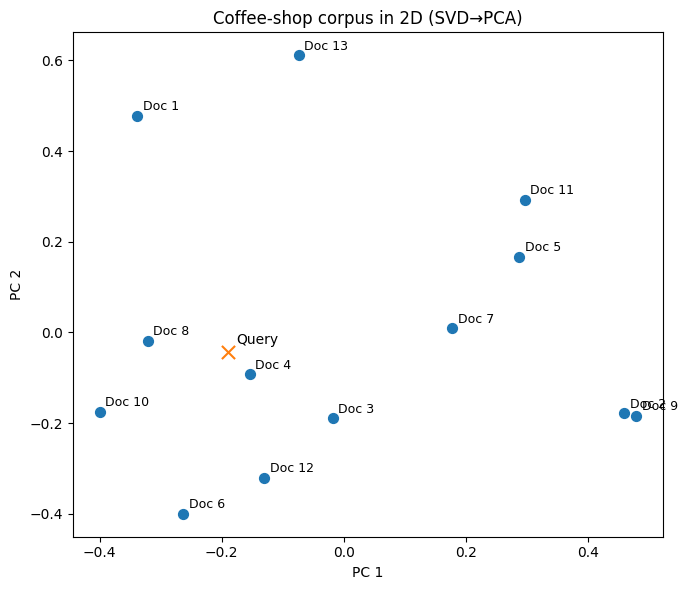

In [ ]:
# Plot with your query on the map
plot_corpus(E2, labels, new_point=q2)

## Production RAG vs This Demo

| Aspect | This demo | Production RAG |
|--------|-----------|----------------|
| Embeddings | TF-IDF + SVD | Neural (BERT, OpenAI) |
| Semantic understanding | Lexical only | Full semantics |
| Similarity search | Brute-force cosine | ANN (FAISS, Pinecone, Chroma) |
| Corpus size | 13 docs | Millions of chunks |
| Generation step | Not included | LLM (GPT-4, Claude, etc.) |

## Reflection Questions

1. **The semantic gap.** TF-IDF would give zero similarity between "café" and "coffee" despite their identical meaning. Give two more concrete examples where TF-IDF retrieval would fail but a neural embedding model would succeed.

2. **Cosine vs Euclidean.** Why is cosine distance preferred for text embeddings? Construct a counterexample where two documents have very different Euclidean distance but identical cosine distance.

3. **Approximate nearest neighbour (ANN).** For 1 million documents, brute-force cosine search requires 1M dot products per query. Algorithms like HNSW (used in FAISS) reduce this to $O(\log N)$. What property of the embedding space enables this speedup, and what accuracy tradeoff is made?

4. **Extending to neural embeddings.** How would you replace TF-IDF with `sentence-transformers`? Write pseudocode showing the key change (just the embedding step, not the full retrieval pipeline).

## Answers

**1. Semantic gap examples.**
- "cheap" vs "affordable" vs "budget-friendly" — TF-IDF: zero overlap; neural: high similarity
- "I loved it" vs "Fantastic, highly recommend" — TF-IDF: no shared terms; neural: very close in sentiment space

**2. Cosine vs Euclidean.**
A short document "espresso café" and a long document with the same words repeated 100 times would have very different $\ell_2$ norms (large Euclidean distance) but identical cosine similarity (same direction). Text length should not affect semantic similarity.

**3. ANN speedup.**
ANN algorithms exploit the fact that high-dimensional embedding spaces have *cluster structure* — nearby points tend to stay nearby under projection or graph traversal. HNSW builds a hierarchical graph of proximity; search traverses from coarse to fine layers in $O(\log N)$ hops. The tradeoff: occasionally the exact nearest neighbour is missed (recall < 100%).

**4. Neural embeddings pseudocode.**
```python
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
E = model.encode(docs)             # shape: (N, 384)
q = model.encode([query_text])[0]  # shape: (384,)
# then use the same cosine nearest_neighbors function
```